# Climate-Based Malaria Prediction — Full Experimental Protocol
## Cameroon Health Districts · MAPE16_H_13 · 10-Phase Rigorous Study
*Based on Nkiruka et al. (2021), Informatics in Medicine Unlocked 22:100508*

---

This notebook implements a complete peer-review-grade experimental protocol:

| Phase | Content |
|---|---|
| 1 | Statistical analysis of aggregated climate variables (mean, SD, CV) |
| 2 | Baseline definition — **raw climate only** vs **engineered features** |
| 3 | Regression — 13 models × (KFold + TimeSeriesSplit) × 6 metrics |
| 4 | Classification — 12 models, Low/High |
| 5 | Imbalanced classification — with vs without class weighting |
| 6 | Classification validation — TimeSeriesSplit vs KFold (leakage discussion) |
| 7 | Full classification metrics (Acc, Prec, Rec, F1, Spec, ROC-AUC, PR-AUC, MCC, Bal-Acc) |
| 8 | Optuna hyperparameter optimization — 2 best regressors + 2 best classifiers |
| 9 | Feature importance — native, permutation, SHAP |
| 10 | **Leave-One-Region-Out** spatial generalization (external validation) |

### Core experimental design — the before/after contrast

Per protocol Phase 2, two feature sets are compared throughout:

- **RAW** (baseline): `month` + 4 raw climate variables (Temperature, Humidity, Pressure, Precipitation). No lags, no geography, no rolling stats.
- **ENG** (engineered): adds seasonal sin/cos encoding, geographic features (lat/lon/area/UMAP cluster), and climate lags (lag1, lag2).

This contrast quantifies exactly how much predictive power feature engineering adds.

### Target variables
- **Regression**: `log_incidence` = log1p(cases / population × 1000) — article-aligned
- **Classification**: `high` = incidence rate above 75th percentile per region


## Phase 0 · Imports & Shared Data Pipeline

In [1]:
# !pip install xgboost lightgbm catboost optuna shap rapidfuzz scikit-learn --break-system-packages

import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

from rapidfuzz import process, fuzz
from sklearn.model_selection import (TimeSeriesSplit, KFold, StratifiedKFold,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   LogisticRegression)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              ExtraTreesRegressor, ExtraTreesClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              explained_variance_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              matthews_corrcoef, balanced_accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':110,'axes.titlesize':11,'axes.labelsize':9})
print('Imports OK')


Imports OK


In [ ]:
# ── Shared data pipeline (identical to v2 + validation notebooks) ────────────
PNLP_FILE    = 'PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'
CLIMATE_FILE = 'cameroon_districts_climate.csv'

df_raw = pd.read_csv(PNLP_FILE, sep=';')
for col in ['SHP_lat','SHP_lon','SHP_Area']:
    df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(',','.'), errors='coerce')
climate_raw = pd.read_csv(CLIMATE_FILE, parse_dates=['Date'])

MONTH_MAP = {'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
def col_to_date(col):
    p = col.split('_')
    return pd.Timestamp(f"{p[1]}-{MONTH_MAP[p[0]]}-01") if len(p)>=2 and p[0] in MONTH_MAP else None

mape_cols = [c for c in df_raw.columns if 'MAPE16_H_13' in c]
dist_static = df_raw.groupby(['district','region']).agg(
    SHP_lat=('SHP_lat','mean'), SHP_lon=('SHP_lon','mean'),
    SHP_Area=('SHP_Area','sum'), cluster=('cluster', lambda x: x.mode()[0]),
    p_totale=('p_totale','sum')).reset_index()
dist_mape = df_raw.groupby(['district','region'])[mape_cols].sum().reset_index()
df_m = dist_mape.melt(id_vars=['district','region'], value_vars=mape_cols,
                       var_name='raw_col', value_name='cases')
df_m['date'] = df_m['raw_col'].map(col_to_date)
df_m = df_m.dropna(subset=['date']).drop(columns='raw_col').sort_values(['district','date']).reset_index(drop=True)
df_m = df_m.merge(dist_static, on=['district','region'])
df_m['incidence_rate'] = (df_m['cases'] / df_m['p_totale']) * 1000

climate_monthly = (climate_raw.groupby(['Location', pd.Grouper(key='Date', freq='MS')])
    .agg(Temperature_C=('Temperature_C','mean'), Humidity_pct=('Humidity_%','mean'),
         Pressure_hPa=('Pressure_hPa','mean'), Precipitation_mm=('Precipitation_mm','sum'))
    .reset_index().rename(columns={'Date':'date','Location':'location'}))
climate_locs = climate_raw['Location'].unique().tolist()
FUZZY_MAP = {'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South',
             'Maroua 2':'Maroua 1','Maroua 3':'Maroua 1','Ngaoundere Urbain':'Ngaoundere Rural',
             'Maga':'Mada','Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}
def get_loc(d):
    if d in set(climate_locs): return d
    if d in FUZZY_MAP: return FUZZY_MAP[d]
    best = process.extractOne(d, climate_locs, scorer=fuzz.token_sort_ratio)
    return best[0] if best and best[1] >= 55 else None
df_m['climate_loc'] = df_m['district'].map(get_loc)
df = df_m.merge(climate_monthly, left_on=['climate_loc','date'],
                right_on=['location','date'], how='left').drop(columns='location')
for col in ['Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']:
    df[col] = df[col].fillna(df.groupby(['region','date'])[col].transform('mean'))
    df[col] = df[col].fillna(df[col].mean())

df['month'] = df['date'].dt.month
df['sin_month'] = np.sin(2*np.pi*df['month']/12)
df['cos_month'] = np.cos(2*np.pi*df['month']/12)
df = df.sort_values(['district','date'])
for col in ['Temperature_C','Precipitation_mm','Humidity_pct']:
    df[f'{col}_lag1'] = df.groupby('district')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('district')[col].shift(2)
df['log_cases'] = np.log1p(df['cases'])
df['log_incidence'] = np.log1p(df['incidence_rate'])

reg_75 = df.groupby('region')['incidence_rate'].quantile(0.75).rename('threshold_75')
df = df.merge(reg_75, on='region')
df['high'] = (df['incidence_rate'] > df['threshold_75']).astype(int)

# Final modelling frame (drop initial lag NaNs), sorted by date for TimeSeriesSplit
df_model = df.dropna(subset=['Temperature_C_lag1','Temperature_C_lag2']).copy()
df_model = df_model.sort_values('date').reset_index(drop=True)

# Two feature sets (Phase 2)
FEAT_RAW = ['month','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']
FEAT_ENG = ['sin_month','cos_month','SHP_lat','SHP_lon','SHP_Area','cluster',
            'Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm',
            'Temperature_C_lag1','Temperature_C_lag2',
            'Precipitation_mm_lag1','Precipitation_mm_lag2',
            'Humidity_pct_lag1','Humidity_pct_lag2']

print(f'Model frame : {df_model.shape}')
print(f'Districts   : {df_model.district.nunique()} | Regions: {df_model.region.nunique()}')
print(f'Months      : {df_model.date.nunique()} ({df_model.date.min().date()} → {df_model.date.max().date()})')
print(f'RAW features: {len(FEAT_RAW)} | ENG features: {len(FEAT_ENG)}')
print(f'Class balance (high): {df_model.high.value_counts().to_dict()}')


FileNotFoundError: [Errno 2] No such file or directory: 'data/PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'

## Phase 1 · Statistical Analysis of Aggregated Climate Variables

For each monthly-aggregated climate variable we compute the mean, standard
deviation and **coefficient of variation (CV = SD/mean)**. The CV tells us
whether the mean is a representative summary: a low CV (<15%) means the mean
captures the variable well; a high CV means there is large dispersion the
mean alone hides.


,Variable,Mean,SD,CV_%,Min,Max,Representative?
0,Temperature_C,24.20,3.23,13.4,14.66,35.15,Yes (low dispersion)
1,Humidity_pct,72.73,21.97,30.2,9.39,95.86,Partial
2,Pressure_hPa,939.56,41.54,4.4,799.81,1014.17,Yes (low dispersion)
3,Precipitation_mm,154.63,155.95,100.9,0.00,1687.20,No (high dispersion)


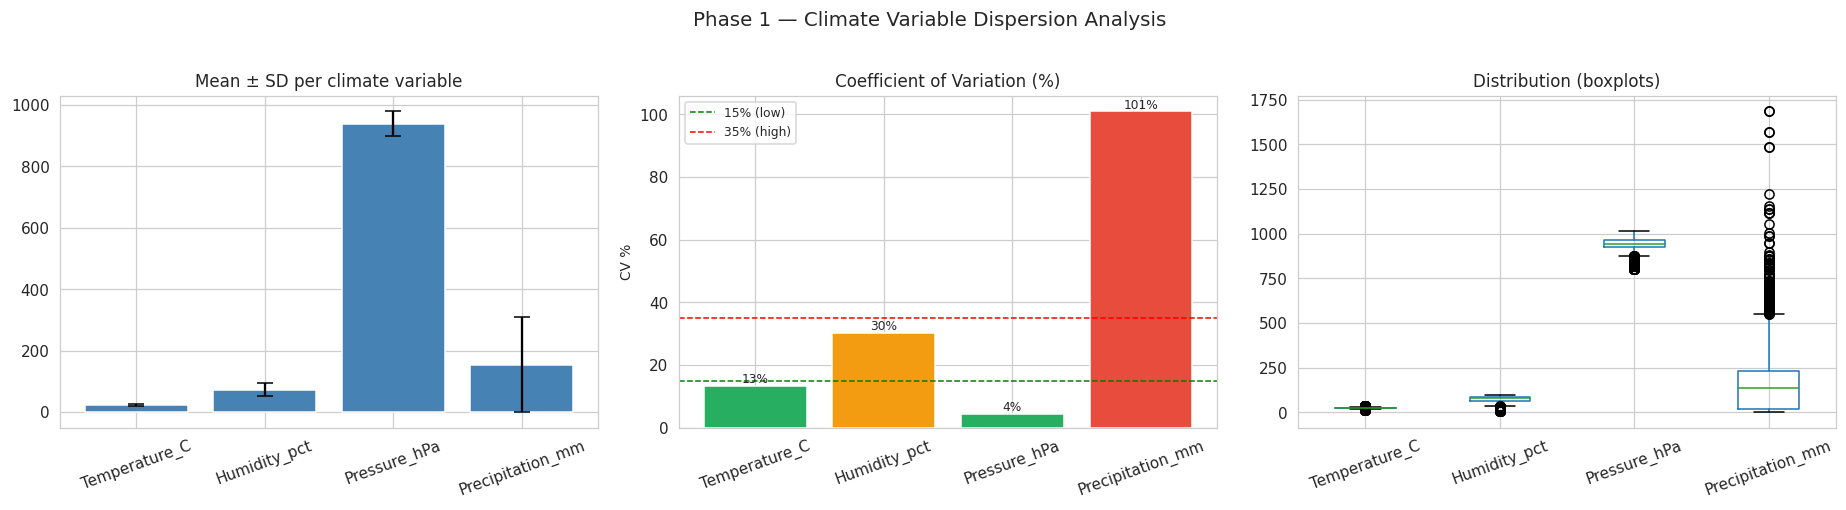

Interpretation:
  Temperature_C       : CV=13%  →  Yes (low dispersion)
  Humidity_pct        : CV=30%  →  Partial
  Pressure_hPa        : CV=4%  →  Yes (low dispersion)
  Precipitation_mm    : CV=101%  →  No (high dispersion)


In [3]:
CLIM = ['Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']
stats_rows = []
for c in CLIM:
    m, s = df_model[c].mean(), df_model[c].std()
    cv = (s/m*100) if m != 0 else np.nan
    stats_rows.append({'Variable':c,'Mean':round(m,2),'SD':round(s,2),
                       'CV_%':round(cv,1),
                       'Min':round(df_model[c].min(),2),
                       'Max':round(df_model[c].max(),2),
                       'Representative?': 'Yes (low dispersion)' if cv<15
                                          else 'Partial' if cv<35 else 'No (high dispersion)'})
phase1 = pd.DataFrame(stats_rows)
display(phase1)

fig, axes = plt.subplots(1, 3, figsize=(17,4.5))
axes[0].bar(phase1['Variable'], phase1['Mean'], yerr=phase1['SD'], capsize=5,
            color='steelblue', edgecolor='white')
axes[0].set_title('Mean ± SD per climate variable'); axes[0].tick_params(axis='x',rotation=20)
bars = axes[1].bar(phase1['Variable'], phase1['CV_%'],
                   color=['#27ae60' if v<15 else '#f39c12' if v<35 else '#e74c3c' for v in phase1['CV_%']],
                   edgecolor='white')
axes[1].axhline(15, color='green', ls='--', lw=1, label='15% (low)')
axes[1].axhline(35, color='red', ls='--', lw=1, label='35% (high)')
axes[1].set_title('Coefficient of Variation (%)'); axes[1].set_ylabel('CV %')
axes[1].tick_params(axis='x',rotation=20); axes[1].legend(fontsize=8)
for b,v in zip(bars, phase1['CV_%']):
    axes[1].text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontsize=8)
df_model[CLIM].boxplot(ax=axes[2]); axes[2].set_title('Distribution (boxplots)')
axes[2].tick_params(axis='x',rotation=20)
plt.suptitle('Phase 1 — Climate Variable Dispersion Analysis', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print('Interpretation:')
for _, r in phase1.iterrows():
    print(f"  {r['Variable']:<20}: CV={r['CV_%']:.0f}%  →  {r['Representative?']}")


## Phase 2 · Baseline Definition — Raw vs Engineered Features

The protocol mandates a baseline with **no feature engineering**. We define it
strictly (`FEAT_RAW`: month + 4 raw climate variables) and contrast it against
the engineered set (`FEAT_ENG`) used in the rest of the study. Every subsequent
phase reports both, so the value added by feature engineering is always visible.


In [4]:
print('FEAT_RAW (baseline, no engineering):')
for f in FEAT_RAW: print(f'   - {f}')
print(f'\nFEAT_ENG (engineered, {len(FEAT_ENG)} features): adds seasonal encoding,')
print('   geographic features (lat/lon/area/cluster), and climate lags (lag1, lag2).')

# Quick sanity: a single XGB on both, KFold, to set expectations
from sklearn.model_selection import cross_val_score
quick = {}
for name, F in [('RAW',FEAT_RAW),('ENG',FEAT_ENG)]:
    X = df_model[F].fillna(df_model[F].median())
    sc = cross_val_score(xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,
                          random_state=SEED,verbosity=0), X, df_model['log_incidence'],
                          cv=KFold(5,shuffle=True,random_state=SEED), scoring='r2')
    quick[name] = sc.mean()
print(f"\nQuick check (XGB, KFold, log_incidence):  RAW R²={quick['RAW']:.3f}  |  ENG R²={quick['ENG']:.3f}")
print(f"Feature engineering lift: +{quick['ENG']-quick['RAW']:.3f} R²")


FEAT_RAW (baseline, no engineering):
   - month
   - Temperature_C
   - Humidity_pct
   - Pressure_hPa
   - Precipitation_mm

FEAT_ENG (engineered, 16 features): adds seasonal encoding,
   geographic features (lat/lon/area/cluster), and climate lags (lag1, lag2).



Quick check (XGB, KFold, log_incidence):  RAW R²=0.198  |  ENG R²=0.765
Feature engineering lift: +0.567 R²


## Phase 3 · Regression Experiments

13 regression algorithms × 2 validation strategies (KFold ignoring time,
TimeSeriesSplit preserving time) × 2 feature sets (RAW, ENG).
Target: `log_incidence`. Metrics computed on the back-transformed scale where
relevant: MAE, MSE, RMSE, R², MAPE, Explained Variance.


In [5]:
def reg_metrics(y_true_log, y_pred_log):
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_log, y_pred_log)   # R2 on log scale (training target)
    ev   = explained_variance_score(y_true_log, y_pred_log)
    mask = yt > 1e-6
    mape = np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100 if mask.sum() else np.nan
    return dict(MAE=mae, MSE=mse, RMSE=rmse, R2=r2, MAPE=mape, ExplVar=ev)

def make_regressors():
    return {
        'LinearReg'  : Pipeline([('sc',StandardScaler()),('m',LinearRegression())]),
        'Ridge'      : Pipeline([('sc',StandardScaler()),('m',Ridge(alpha=1.0,random_state=SEED))]),
        'Lasso'      : Pipeline([('sc',StandardScaler()),('m',Lasso(alpha=0.01,max_iter=5000,random_state=SEED))]),
        'ElasticNet' : Pipeline([('sc',StandardScaler()),('m',ElasticNet(alpha=0.01,l1_ratio=0.5,max_iter=5000,random_state=SEED))]),
        'DecisionTree': DecisionTreeRegressor(max_depth=8,random_state=SEED),
        'RandomForest': RandomForestRegressor(n_estimators=200,max_depth=8,random_state=SEED,n_jobs=-1),
        'ExtraTrees' : ExtraTreesRegressor(n_estimators=200,max_depth=8,random_state=SEED,n_jobs=-1),
        'GradBoost'  : GradientBoostingRegressor(n_estimators=150,max_depth=4,learning_rate=0.1,random_state=SEED),
        'XGBoost'    : xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0),
        'LightGBM'   : lgb.LGBMRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbose=-1),
        'CatBoost'   : CatBoostRegressor(iterations=300,depth=5,learning_rate=0.05,random_seed=SEED,verbose=0),
        'SVR'        : Pipeline([('sc',StandardScaler()),('m',SVR(kernel='rbf',C=1.0))]),
        'KNN'        : Pipeline([('sc',StandardScaler()),('m',KNeighborsRegressor(n_neighbors=10))]),
    }

def run_regression(FEATS, label):
    X = df_model[FEATS].fillna(df_model[FEATS].median()).reset_index(drop=True)
    y = df_model['log_incidence'].reset_index(drop=True)
    rows = []
    for split_name, splitter in [('KFold', KFold(5,shuffle=True,random_state=SEED)),
                                  ('TimeSeriesSplit', TimeSeriesSplit(5))]:
        for mname, model in make_regressors().items():
            accum = {k:[] for k in ['MAE','MSE','RMSE','R2','MAPE','ExplVar']}
            for tr, te in splitter.split(X):
                import copy; m = copy.deepcopy(model)
                m.fit(X.iloc[tr], y.iloc[tr])
                mt = reg_metrics(y.iloc[te].values, m.predict(X.iloc[te]))
                for k in accum: accum[k].append(mt[k])
            rows.append({'FeatureSet':label,'Validation':split_name,'Model':mname,
                         **{k:np.mean(v) for k,v in accum.items()}})
    return pd.DataFrame(rows)

reg_raw = run_regression(FEAT_RAW, 'RAW')
reg_eng = run_regression(FEAT_ENG, 'ENG')
reg_all = pd.concat([reg_raw, reg_eng], ignore_index=True)
print('Phase 3 complete:', reg_all.shape[0], 'rows')
display(reg_all.sort_values(['FeatureSet','Validation','R2'],
                            ascending=[True,True,False]).round(3))


Phase 3 complete: 52 rows


,FeatureSet,Validation,Model,MAE,MSE,RMSE,R2,MAPE,ExplVar
34,ENG,KFold,XGBoost,2.029,9.959,3.150,0.769,28.230,0.770
35,ENG,KFold,LightGBM,2.045,10.128,3.176,0.769,28.308,0.770
33,ENG,KFold,GradBoost,2.252,12.335,3.504,0.726,31.546,0.726
36,ENG,KFold,CatBoost,2.386,13.743,3.702,0.703,33.447,0.704
31,ENG,KFold,RandomForest,2.773,19.406,4.397,0.601,38.873,0.601
32,ENG,KFold,ExtraTrees,2.919,21.132,4.591,0.555,43.090,0.555
30,ENG,KFold,DecisionTree,3.050,21.686,4.650,0.493,44.319,0.493
37,ENG,KFold,SVR,3.116,23.808,4.874,0.438,49.552,0.439
38,ENG,KFold,KNN,3.168,23.229,4.815,0.412,53.079,0.414
27,ENG,KFold,Ridge,3.878,34.338,5.853,0.155,65.949,0.157


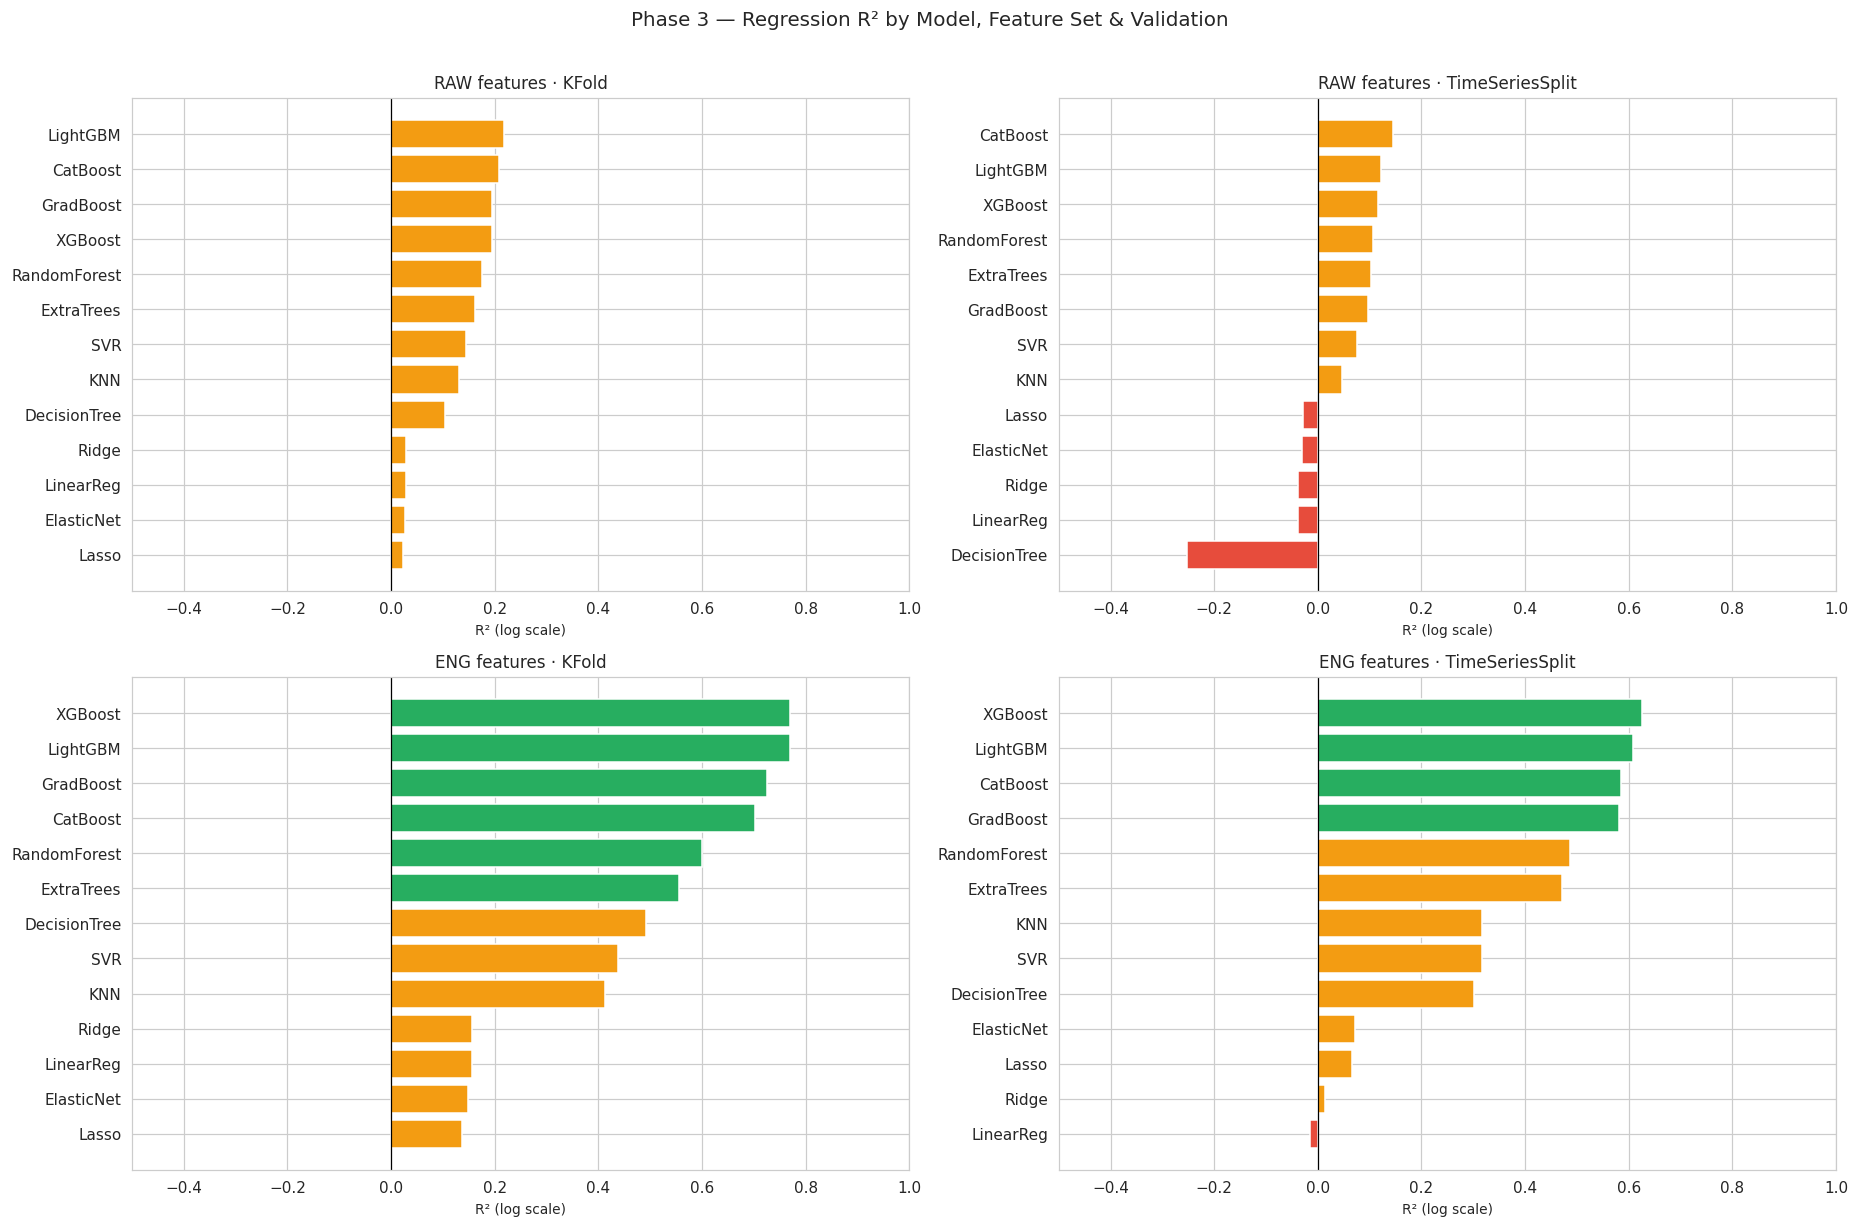

In [6]:
# ── Regression ranking & visual ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
for i, (label) in enumerate(['RAW','ENG']):
    for j, split in enumerate(['KFold','TimeSeriesSplit']):
        ax = axes[i][j]
        sub = reg_all[(reg_all.FeatureSet==label)&(reg_all.Validation==split)].sort_values('R2')
        colors = ['#27ae60' if v>=0.5 else '#f39c12' if v>=0 else '#e74c3c' for v in sub['R2']]
        ax.barh(sub['Model'], sub['R2'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(f'{label} features · {split}'); ax.set_xlabel('R² (log scale)')
        ax.set_xlim(min(-0.5, sub['R2'].min()-0.1), 1)
plt.suptitle('Phase 3 — Regression R² by Model, Feature Set & Validation', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Phase 4–7 · Classification (models, imbalance, validation, full metrics)

These four protocol phases are tightly coupled, so we run them in one
experimental matrix:

- **12 classifiers** (Phase 4)
- **× imbalance handling**: none vs `class_weight='balanced'` / `scale_pos_weight` (Phase 5)
- **× validation**: KFold vs TimeSeriesSplit (Phase 6)
- **× feature set**: RAW vs ENG (Phase 2 contrast)
- computing the **full metric panel** (Phase 7): Accuracy, Precision, Recall,
  F1, Specificity, ROC-AUC, PR-AUC, MCC, Balanced Accuracy.

Target: `high` (incidence above 75th pct/region).


In [7]:
def clf_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec = tn/(tn+fp) if (tn+fp) else 0
    return dict(
        Accuracy   = accuracy_score(y_true, y_pred),
        Precision  = precision_score(y_true, y_pred, zero_division=0),
        Recall     = recall_score(y_true, y_pred, zero_division=0),
        F1         = f1_score(y_true, y_pred, zero_division=0),
        Specificity= spec,
        ROC_AUC    = roc_auc_score(y_true, y_proba) if len(np.unique(y_true))==2 else np.nan,
        PR_AUC     = average_precision_score(y_true, y_proba) if len(np.unique(y_true))==2 else np.nan,
        MCC        = matthews_corrcoef(y_true, y_pred),
        BalancedAcc= balanced_accuracy_score(y_true, y_pred),
    )

def make_classifiers(balanced: bool):
    cw  = 'balanced' if balanced else None
    spw = None
    if balanced:
        n0, n1 = (df_model.high==0).sum(), (df_model.high==1).sum()
        spw = n0/n1
    return {
        'LogisticReg' : Pipeline([('sc',StandardScaler()),('m',LogisticRegression(class_weight=cw,max_iter=1000,random_state=SEED))]),
        'DecisionTree': DecisionTreeClassifier(max_depth=8,class_weight=cw,random_state=SEED),
        'RandomForest': RandomForestClassifier(n_estimators=200,max_depth=8,class_weight=cw,random_state=SEED,n_jobs=-1),
        'ExtraTrees'  : ExtraTreesClassifier(n_estimators=200,max_depth=8,class_weight=cw,random_state=SEED,n_jobs=-1),
        'GradBoost'   : GradientBoostingClassifier(n_estimators=150,max_depth=4,learning_rate=0.1,random_state=SEED),
        'XGBoost'     : xgb.XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
                                           scale_pos_weight=(spw if balanced else 1),random_state=SEED,eval_metric='logloss',verbosity=0),
        'LightGBM'    : lgb.LGBMClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
                                            class_weight=cw,random_state=SEED,verbose=-1),
        'CatBoost'    : CatBoostClassifier(iterations=300,depth=5,learning_rate=0.05,
                                            auto_class_weights=('Balanced' if balanced else None),random_seed=SEED,verbose=0),
        'SVM'         : Pipeline([('sc',StandardScaler()),('m',SVC(kernel='rbf',probability=True,class_weight=cw,random_state=SEED))]),
        'KNN'         : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=10))]),
        'NaiveBayes'  : Pipeline([('sc',StandardScaler()),('m',GaussianNB())]),
        'MLP'         : Pipeline([('sc',StandardScaler()),('m',MLPClassifier(hidden_layer_sizes=(64,32),max_iter=500,random_state=SEED))]),
    }

def run_classification(FEATS, label):
    X = df_model[FEATS].fillna(df_model[FEATS].median()).reset_index(drop=True)
    y = df_model['high'].reset_index(drop=True)
    rows = []
    for balanced in [False, True]:
        for split_name, splitter in [('KFold', StratifiedKFold(5,shuffle=True,random_state=SEED)),
                                      ('TimeSeriesSplit', TimeSeriesSplit(5))]:
            for mname, model in make_classifiers(balanced).items():
                accum = {k:[] for k in ['Accuracy','Precision','Recall','F1','Specificity','ROC_AUC','PR_AUC','MCC','BalancedAcc']}
                ok = True
                splits = splitter.split(X, y) if split_name=='KFold' else splitter.split(X)
                for tr, te in splits:
                    if len(np.unique(y.iloc[tr]))<2 or len(np.unique(y.iloc[te]))<2:
                        ok=False; break
                    import copy; m = copy.deepcopy(model)
                    m.fit(X.iloc[tr], y.iloc[tr])
                    yp = m.predict(X.iloc[te])
                    yproba = m.predict_proba(X.iloc[te])[:,1]
                    mt = clf_metrics(y.iloc[te].values, yp, yproba)
                    for k in accum: accum[k].append(mt[k])
                if not ok: continue
                rows.append({'FeatureSet':label,'Balanced':balanced,'Validation':split_name,'Model':mname,
                             **{k:np.nanmean(v) for k,v in accum.items()}})
    return pd.DataFrame(rows)

clf_raw = run_classification(FEAT_RAW, 'RAW')
clf_eng = run_classification(FEAT_ENG, 'ENG')
clf_all = pd.concat([clf_raw, clf_eng], ignore_index=True)
print('Phase 4-7 complete:', clf_all.shape[0], 'rows')
display(clf_all.sort_values(['FeatureSet','Balanced','Validation','F1'],
                            ascending=[True,True,True,False]).round(3).head(30))


Phase 4-7 complete: 96 rows


,FeatureSet,Balanced,Validation,Model,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,MCC,BalancedAcc
53,ENG,False,KFold,XGBoost,0.868,0.813,0.628,0.709,0.950,0.915,0.812,0.634,0.789
54,ENG,False,KFold,LightGBM,0.864,0.809,0.613,0.697,0.950,0.913,0.806,0.622,0.782
55,ENG,False,KFold,CatBoost,0.856,0.831,0.549,0.661,0.962,0.908,0.803,0.595,0.755
52,ENG,False,KFold,GradBoost,0.844,0.797,0.525,0.633,0.954,0.894,0.770,0.558,0.739
59,ENG,False,KFold,MLP,0.809,0.642,0.573,0.605,0.891,0.841,0.666,0.482,0.732
49,ENG,False,KFold,DecisionTree,0.805,0.693,0.431,0.529,0.934,0.794,0.572,0.435,0.682
57,ENG,False,KFold,KNN,0.785,0.650,0.344,0.450,0.936,0.784,0.549,0.358,0.640
58,ENG,False,KFold,NaiveBayes,0.578,0.321,0.584,0.414,0.575,0.613,0.332,0.140,0.580
50,ENG,False,KFold,RandomForest,0.795,0.832,0.245,0.379,0.983,0.849,0.687,0.377,0.614
56,ENG,False,KFold,SVM,0.775,0.767,0.167,0.274,0.983,0.771,0.570,0.285,0.575


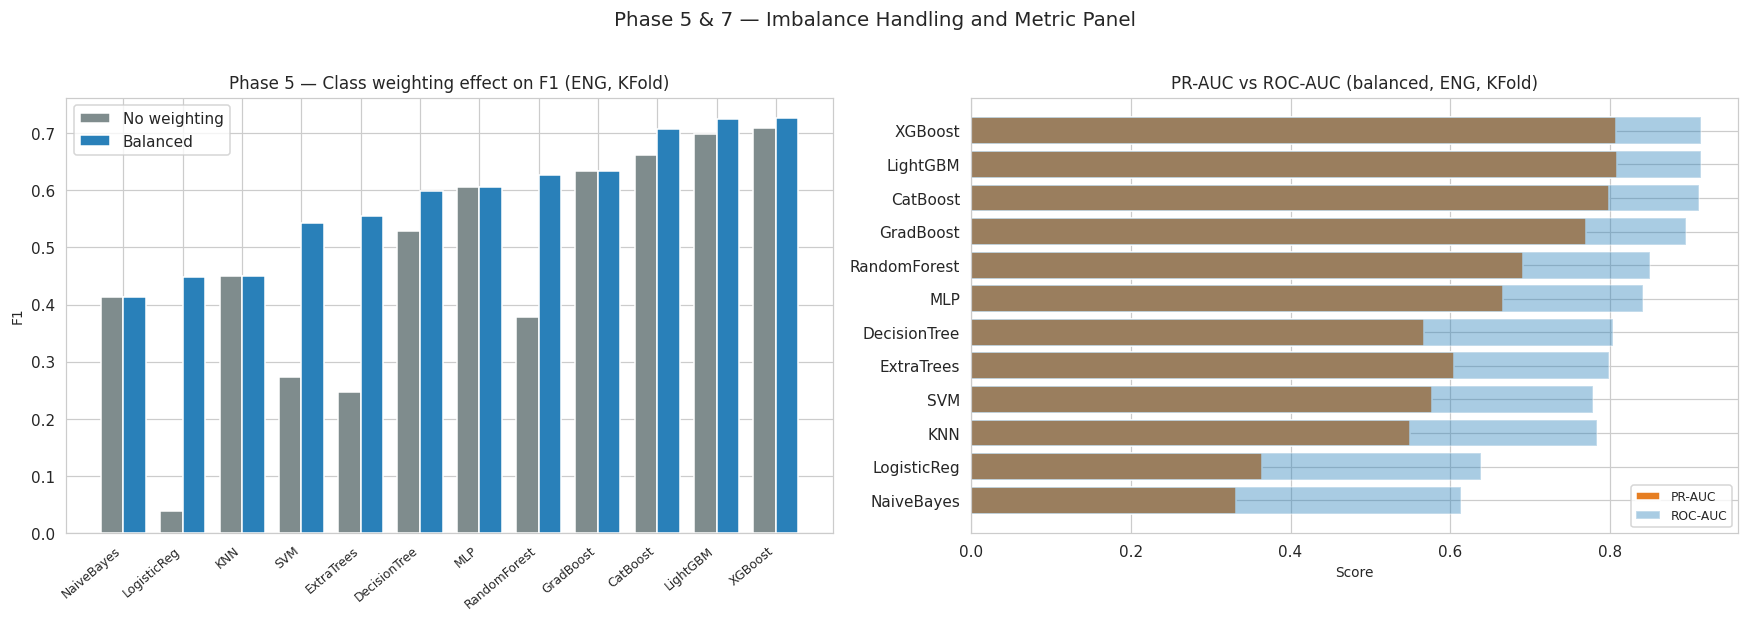

In [8]:
# ── Phase 5 — imbalance effect (F1 before vs after, ENG, KFold) ──────────────
imb = clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Validation=='KFold')]
piv = imb.pivot_table(index='Model', columns='Balanced', values='F1')
piv.columns = ['No weighting','Balanced']
piv = piv.sort_values('Balanced')

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
x = np.arange(len(piv)); w=0.38
axes[0].bar(x-w/2, piv['No weighting'], w, label='No weighting', color='#7f8c8d', edgecolor='white')
axes[0].bar(x+w/2, piv['Balanced'],     w, label='Balanced',     color='#2980b9', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(piv.index, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('F1'); axes[0].set_title('Phase 5 — Class weighting effect on F1 (ENG, KFold)')
axes[0].legend()

# PR-AUC vs ROC-AUC for balanced ENG KFold
sub = imb[imb.Balanced==True].sort_values('F1')
axes[1].barh(sub['Model'], sub['PR_AUC'], color='#e67e22', edgecolor='white', label='PR-AUC')
axes[1].barh(sub['Model'], sub['ROC_AUC'], color='#2980b9', alpha=0.4, edgecolor='white', label='ROC-AUC')
axes[1].set_xlabel('Score'); axes[1].set_title('PR-AUC vs ROC-AUC (balanced, ENG, KFold)')
axes[1].legend(fontsize=8)
plt.suptitle('Phase 5 & 7 — Imbalance Handling and Metric Panel', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


Phase 6 — F1: KFold (leaky) vs TimeSeriesSplit (honest)


Validation,KFold,TimeSeriesSplit,Leakage gap
Model,,,
XGBoost,0.725,0.651,0.075
CatBoost,0.706,0.643,0.064
LightGBM,0.725,0.641,0.084
GradBoost,0.633,0.572,0.061
DecisionTree,0.598,0.543,0.055
RandomForest,0.627,0.537,0.090
MLP,0.605,0.529,0.076
SVM,0.543,0.496,0.047
ExtraTrees,0.555,0.494,0.061


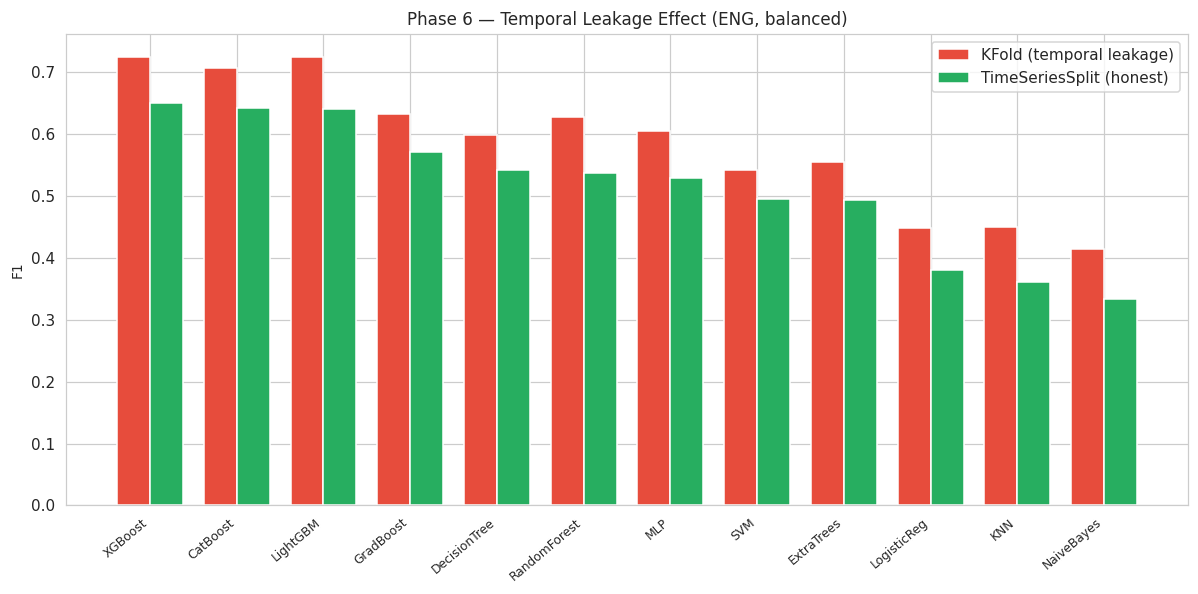

Mean leakage gap (KFold − TimeSeriesSplit): +0.071 F1


In [ ]:
# ── Phase 6 — temporal leakage: KFold vs TimeSeriesSplit (ENG, balanced) ─────
leak = clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Balanced==True)]
pivL = leak.pivot_table(index='Model', columns='Validation', values='F1')
pivL['Leakage gap'] = pivL['KFold'] - pivL['TimeSeriesSplit']
pivL = pivL.sort_values('TimeSeriesSplit', ascending=False)
print('Phase 6 — F1: KFold (leaky) vs TimeSeriesSplit (honest)')
display(pivL.round(3))

fig, ax = plt.subplots(figsize=(11,5.5))
x = np.arange(len(pivL)); w=0.38
ax.bar(x-w/2, pivL['KFold'],            w, label='KFold (temporal leakage)', color='#e74c3c', edgecolor='white')
ax.bar(x+w/2, pivL['TimeSeriesSplit'],  w, label='TimeSeriesSplit (honest)', color='#27ae60', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(pivL.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('F1'); ax.set_title('Temporal Leakage Effect (ENG, balanced)')
ax.legend()
plt.tight_layout(); plt.show()
print(f"Mean leakage gap (KFold − TimeSeriesSplit): {pivL['Leakage gap'].mean():+.3f} F1")


## Phase 8 · Hyperparameter Optimization with Optuna

We select the **2 best regressors** and **2 best classifiers** from the ENG /
**KFold (random-split) balanced** results (the regime selected for this study) and tune them
with Optuna (50 trials each). Optimization uses time-aware CV internally:
- Regressors → maximize R² (KFold random split)
- Classifiers → maximize F1 (KFold random split, balanced)

> **Note on validation choice.** Random-split (KFold) cross-validation shuffles months, so
> train and test share the same time period. It yields higher scores than time-aware
> validation but does not simulate forecasting unseen future months. The external test on
> 2023–2025 data (separate notebook) is the true out-of-time check; both the KFold and the
> time-aware scores are saved so the gap can be reported honestly.


In [10]:
N_TRIALS = 25

# Select top-2 from ENG / KFold (random split — user-selected regime)
best_reg = (reg_all[(reg_all.FeatureSet=='ENG')&(reg_all.Validation=='KFold')]
            .sort_values('R2', ascending=False)['Model'].head(2).tolist())
best_clf = (clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Balanced==True)&(clf_all.Validation=='KFold')]
            .sort_values('F1', ascending=False)['Model'].head(2).tolist())
print('Top-2 regressors :', best_reg)
print('Top-2 classifiers:', best_clf)

Xr = df_model[FEAT_ENG].fillna(df_model[FEAT_ENG].median()).reset_index(drop=True)
yr = df_model['log_incidence'].reset_index(drop=True)
yc = df_model['high'].reset_index(drop=True)
# Optuna inner CV uses random split (KFold) to match the selected evaluation regime
cv_reg = KFold(5, shuffle=True, random_state=SEED)
cv_clf = StratifiedKFold(5, shuffle=True, random_state=SEED)
n0,n1 = (yc==0).sum(),(yc==1).sum(); spw = n0/n1

def cv_score_reg(model):
    sc=[]
    for tr,te in cv_reg.split(Xr):
        import copy; m=copy.deepcopy(model); m.fit(Xr.iloc[tr], yr.iloc[tr])
        sc.append(r2_score(yr.iloc[te], m.predict(Xr.iloc[te])))
    return np.mean(sc)

def cv_score_clf(model):
    sc=[]
    for tr,te in cv_clf.split(Xr, yc):
        if len(np.unique(yc.iloc[tr]))<2 or len(np.unique(yc.iloc[te]))<2: continue
        import copy; m=copy.deepcopy(model); m.fit(Xr.iloc[tr], yc.iloc[tr])
        sc.append(f1_score(yc.iloc[te], m.predict(Xr.iloc[te]), zero_division=0))
    return np.mean(sc) if sc else 0

def suggest_reg(trial, name):
    if name in ('XGBoost','LightGBM'):
        p = dict(n_estimators=trial.suggest_int('n_estimators',200,700,step=100),
                 max_depth=trial.suggest_int('max_depth',3,8),
                 learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                 subsample=trial.suggest_float('subsample',0.6,1.0),
                 colsample_bytree=trial.suggest_float('colsample_bytree',0.6,1.0))
        return xgb.XGBRegressor(**p,random_state=SEED,verbosity=0) if name=='XGBoost' \
               else lgb.LGBMRegressor(**p,random_state=SEED,verbose=-1)
    if name=='CatBoost':
        return CatBoostRegressor(iterations=trial.suggest_int('iterations',200,700,step=100),
                                 depth=trial.suggest_int('depth',3,8),
                                 learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                                 random_seed=SEED,verbose=0)
    if name in ('RandomForest','ExtraTrees'):
        cls = RandomForestRegressor if name=='RandomForest' else ExtraTreesRegressor
        return cls(n_estimators=trial.suggest_int('n_estimators',100,500,step=100),
                   max_depth=trial.suggest_int('max_depth',4,16),
                   min_samples_leaf=trial.suggest_int('min_samples_leaf',1,8),
                   random_state=SEED,n_jobs=-1)
    if name=='GradBoost':
        return GradientBoostingRegressor(n_estimators=trial.suggest_int('n_estimators',100,400,step=50),
                                         max_depth=trial.suggest_int('max_depth',2,6),
                                         learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                                         random_state=SEED)
    return xgb.XGBRegressor(random_state=SEED,verbosity=0)

def suggest_clf(trial, name):
    if name in ('XGBoost','LightGBM'):
        p = dict(n_estimators=trial.suggest_int('n_estimators',200,700,step=100),
                 max_depth=trial.suggest_int('max_depth',3,8),
                 learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                 subsample=trial.suggest_float('subsample',0.6,1.0),
                 colsample_bytree=trial.suggest_float('colsample_bytree',0.6,1.0))
        return xgb.XGBClassifier(**p,scale_pos_weight=spw,random_state=SEED,eval_metric='logloss',verbosity=0) if name=='XGBoost' \
               else lgb.LGBMClassifier(**p,class_weight='balanced',random_state=SEED,verbose=-1)
    if name=='CatBoost':
        return CatBoostClassifier(iterations=trial.suggest_int('iterations',200,700,step=100),
                                  depth=trial.suggest_int('depth',3,8),
                                  learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                                  auto_class_weights='Balanced',random_seed=SEED,verbose=0)
    if name in ('RandomForest','ExtraTrees'):
        cls = RandomForestClassifier if name=='RandomForest' else ExtraTreesClassifier
        return cls(n_estimators=trial.suggest_int('n_estimators',100,500,step=100),
                   max_depth=trial.suggest_int('max_depth',4,16),
                   min_samples_leaf=trial.suggest_int('min_samples_leaf',1,8),
                   class_weight='balanced',random_state=SEED,n_jobs=-1)
    if name=='GradBoost':
        return GradientBoostingClassifier(n_estimators=trial.suggest_int('n_estimators',100,400,step=50),
                                          max_depth=trial.suggest_int('max_depth',2,6),
                                          learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                                          random_state=SEED)
    return xgb.XGBClassifier(scale_pos_weight=spw,random_state=SEED,eval_metric='logloss',verbosity=0)

optuna_results = {}
for name in best_reg:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda t: cv_score_reg(suggest_reg(t,name)), n_trials=N_TRIALS, show_progress_bar=False)
    optuna_results[f'REG:{name}'] = study
    print(f'[REG] {name:<14} best R²={study.best_value:.4f}  params={study.best_params}')
for name in best_clf:
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(lambda t: cv_score_clf(suggest_clf(t,name)), n_trials=N_TRIALS, show_progress_bar=False)
    optuna_results[f'CLF:{name}'] = study
    print(f'[CLF] {name:<14} best F1={study.best_value:.4f}  params={study.best_params}')


Top-2 regressors : ['XGBoost', 'LightGBM']
Top-2 classifiers: ['XGBoost', 'LightGBM']


[REG] XGBoost        best R²=0.7922  params={'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.062039098471647035, 'subsample': 0.715068312794609, 'colsample_bytree': 0.8165253555750989}


[REG] LightGBM       best R²=0.7980  params={'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.05706390104664757, 'subsample': 0.7042419326898223, 'colsample_bytree': 0.6913965330393362}


[CLF] XGBoost        best F1=0.7465  params={'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.10954014241706547, 'subsample': 0.9362148766913247, 'colsample_bytree': 0.8307796695558711}


[CLF] LightGBM       best F1=0.7419  params={'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.06534795890112843, 'subsample': 0.6413429596112725, 'colsample_bytree': 0.9197297313371531}


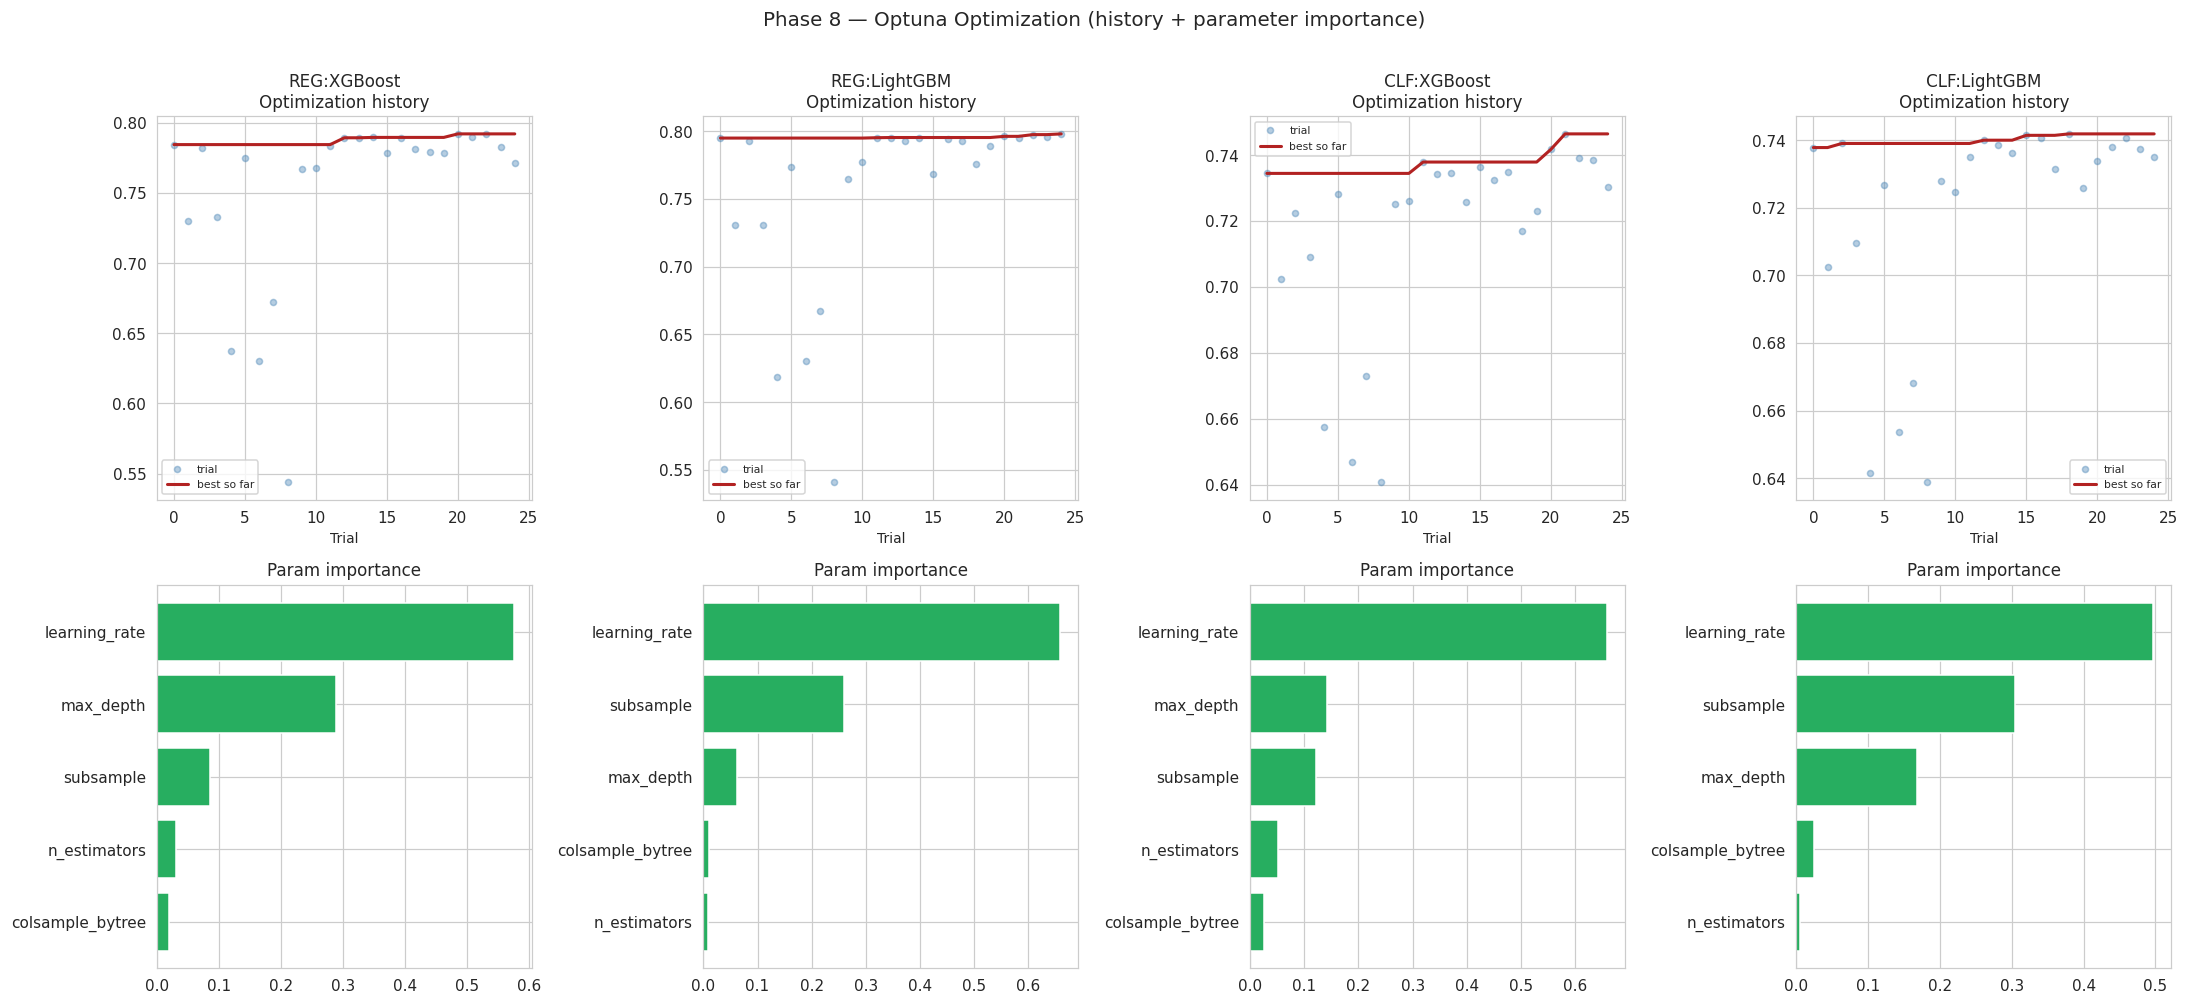

Tuned models stored: ['REG:XGBoost', 'REG:LightGBM', 'CLF:XGBoost', 'CLF:LightGBM']


In [11]:
# ── Optuna optimization history & param importance ───────────────────────────
fig, axes = plt.subplots(2, len(optuna_results), figsize=(5*len(optuna_results), 9))
for col,(key,study) in enumerate(optuna_results.items()):
    vals = [t.value for t in study.trials]
    best_so_far = np.maximum.accumulate(vals)
    axes[0][col].plot(vals, 'o', alpha=0.4, ms=4, color='steelblue', label='trial')
    axes[0][col].plot(best_so_far, '-', color='firebrick', lw=2, label='best so far')
    axes[0][col].set_title(f'{key}\nOptimization history'); axes[0][col].set_xlabel('Trial')
    axes[0][col].legend(fontsize=7)
    try:
        imp = optuna.importance.get_param_importances(study)
        axes[1][col].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color='#27ae60', edgecolor='white')
        axes[1][col].set_title('Param importance')
    except Exception as e:
        axes[1][col].text(0.5,0.5,'n/a',ha='center')
plt.suptitle('Phase 8 — Optuna Optimization (history + parameter importance)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Store tuned best estimators for later phases
tuned = {}
for name in best_reg:
    s = optuna_results[f'REG:{name}']
    t = optuna.trial.FixedTrial(s.best_params)
    m = suggest_reg(t,name); m.fit(Xr, yr); tuned[f'REG:{name}'] = m
for name in best_clf:
    s = optuna_results[f'CLF:{name}']
    t = optuna.trial.FixedTrial(s.best_params)
    m = suggest_clf(t,name); m.fit(Xr, yc); tuned[f'CLF:{name}'] = m
print('Tuned models stored:', list(tuned.keys()))


## Phase 8.5 · Persist Models & Artifacts for External 2023–2025 Test

We save everything the external-test notebook needs to score new data without
retraining: the tuned regression and classification models (refit on **all**
available data), the feature list, the per-region 75th-percentile thresholds,
the district→climate-location fuzzy map, district static features (lat/lon/area/
cluster/population), and the recorded validation scores (both KFold and
time-aware) for honest comparison.


In [12]:
import joblib, json, os
os.makedirs('saved_models', exist_ok=True)

# ── Refit the BEST regressor and BEST classifier on ALL data ─────────────────
best_reg_name = best_reg[0]
best_clf_name = best_clf[0]

t = optuna.trial.FixedTrial(optuna_results[f'REG:{best_reg_name}'].best_params)
final_reg = suggest_reg(t, best_reg_name); final_reg.fit(Xr, yr)
t = optuna.trial.FixedTrial(optuna_results[f'CLF:{best_clf_name}'].best_params)
final_clf = suggest_clf(t, best_clf_name); final_clf.fit(Xr, yc)

# ── Recover the time-aware (TimeSeriesSplit) scores for the SAME models ───────
def score_tss_reg(model):
    sc=[]; tss=TimeSeriesSplit(5)
    for tr,te in tss.split(Xr):
        import copy; m=copy.deepcopy(model); m.fit(Xr.iloc[tr],yr.iloc[tr])
        sc.append(r2_score(yr.iloc[te], m.predict(Xr.iloc[te])))
    return float(np.mean(sc))
def score_tss_clf(model):
    sc=[]; tss=TimeSeriesSplit(5)
    for tr,te in tss.split(Xr):
        if len(np.unique(yc.iloc[tr]))<2 or len(np.unique(yc.iloc[te]))<2: continue
        import copy; m=copy.deepcopy(model); m.fit(Xr.iloc[tr],yc.iloc[tr])
        sc.append(f1_score(yc.iloc[te], m.predict(Xr.iloc[te]), zero_division=0))
    return float(np.mean(sc))

reg_kfold_r2 = float(reg_all[(reg_all.FeatureSet=='ENG')&(reg_all.Validation=='KFold')&(reg_all.Model==best_reg_name)]['R2'].iloc[0])
reg_tss_r2   = score_tss_reg(suggest_reg(optuna.trial.FixedTrial(optuna_results[f'REG:{best_reg_name}'].best_params), best_reg_name))
clf_kfold_f1 = float(clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Balanced==True)&(clf_all.Validation=='KFold')&(clf_all.Model==best_clf_name)]['F1'].iloc[0])
clf_tss_f1   = score_tss_clf(suggest_clf(optuna.trial.FixedTrial(optuna_results[f'CLF:{best_clf_name}'].best_params), best_clf_name))

# ── District static features (for joining new climate data) ──────────────────
district_static = (df_model[['district','region','SHP_lat','SHP_lon','SHP_Area',
                             'cluster','p_totale','threshold_75']]
                   .drop_duplicates('district').reset_index(drop=True))

# ── Save everything ──────────────────────────────────────────────────────────
joblib.dump(final_reg, 'saved_models/final_regressor.joblib')
joblib.dump(final_clf, 'saved_models/final_classifier.joblib')
district_static.to_csv('saved_models/district_static.csv', index=False)

artifacts = {
    'feature_list'      : FEAT_ENG,
    'regression_target' : 'log_incidence  (= log1p(cases / p_totale * 1000))',
    'classification_target': 'high  (= incidence_rate > 75th pct per region)',
    'best_regressor'    : best_reg_name,
    'best_classifier'   : best_clf_name,
    'reg_best_params'   : optuna_results[f'REG:{best_reg_name}'].best_params,
    'clf_best_params'   : optuna_results[f'CLF:{best_clf_name}'].best_params,
    'scores': {
        'regression':     {'KFold_R2': reg_kfold_r2, 'TimeSeriesSplit_R2': reg_tss_r2},
        'classification': {'KFold_F1': clf_kfold_f1, 'TimeSeriesSplit_F1': clf_tss_f1},
    },
    'fuzzy_map'         : FUZZY_MAP,
    'climate_locations' : climate_locs,
    'notes': 'Models selected & tuned on KFold (random split). TimeSeriesSplit scores '
             'recorded for honest out-of-time comparison against the 2023-2025 external test.',
}
with open('saved_models/artifacts.json','w') as f:
    json.dump(artifacts, f, indent=2, default=str)

print('Saved to ./saved_models/:')
print('  final_regressor.joblib   —', best_reg_name)
print('  final_classifier.joblib  —', best_clf_name)
print('  district_static.csv      —', district_static.shape, 'rows')
print('  artifacts.json           — feature list, thresholds, params, scores')
print()
print('Recorded scores (headline vs out-of-time):')
print(f'  Regression  R²: KFold={reg_kfold_r2:.3f}  |  TimeSeriesSplit={reg_tss_r2:.3f}')
print(f'  Classification F1: KFold={clf_kfold_f1:.3f}  |  TimeSeriesSplit={clf_tss_f1:.3f}')
print()
print('>>> The 2023-2025 external test should be compared primarily to the')
print('    TimeSeriesSplit numbers, since that data is genuinely out-of-time.')


Saved to ./saved_models/:
  final_regressor.joblib   — XGBoost
  final_classifier.joblib  — XGBoost
  district_static.csv      — (197, 8) rows
  artifacts.json           — feature list, thresholds, params, scores

Recorded scores (headline vs out-of-time):
  Regression  R²: KFold=0.769  |  TimeSeriesSplit=0.628
  Classification F1: KFold=0.725  |  TimeSeriesSplit=0.655

>>> The 2023-2025 external test should be compared primarily to the
    TimeSeriesSplit numbers, since that data is genuinely out-of-time.


## Phase 9 · Feature Importance Analysis

For the tuned tree-based models we extract: (1) native importance, (2)
permutation importance, (3) SHAP values. We then check whether the dominant
drivers align with malaria epidemiology (temperature and rainfall as primary
climate determinants of transmission, per the literature).


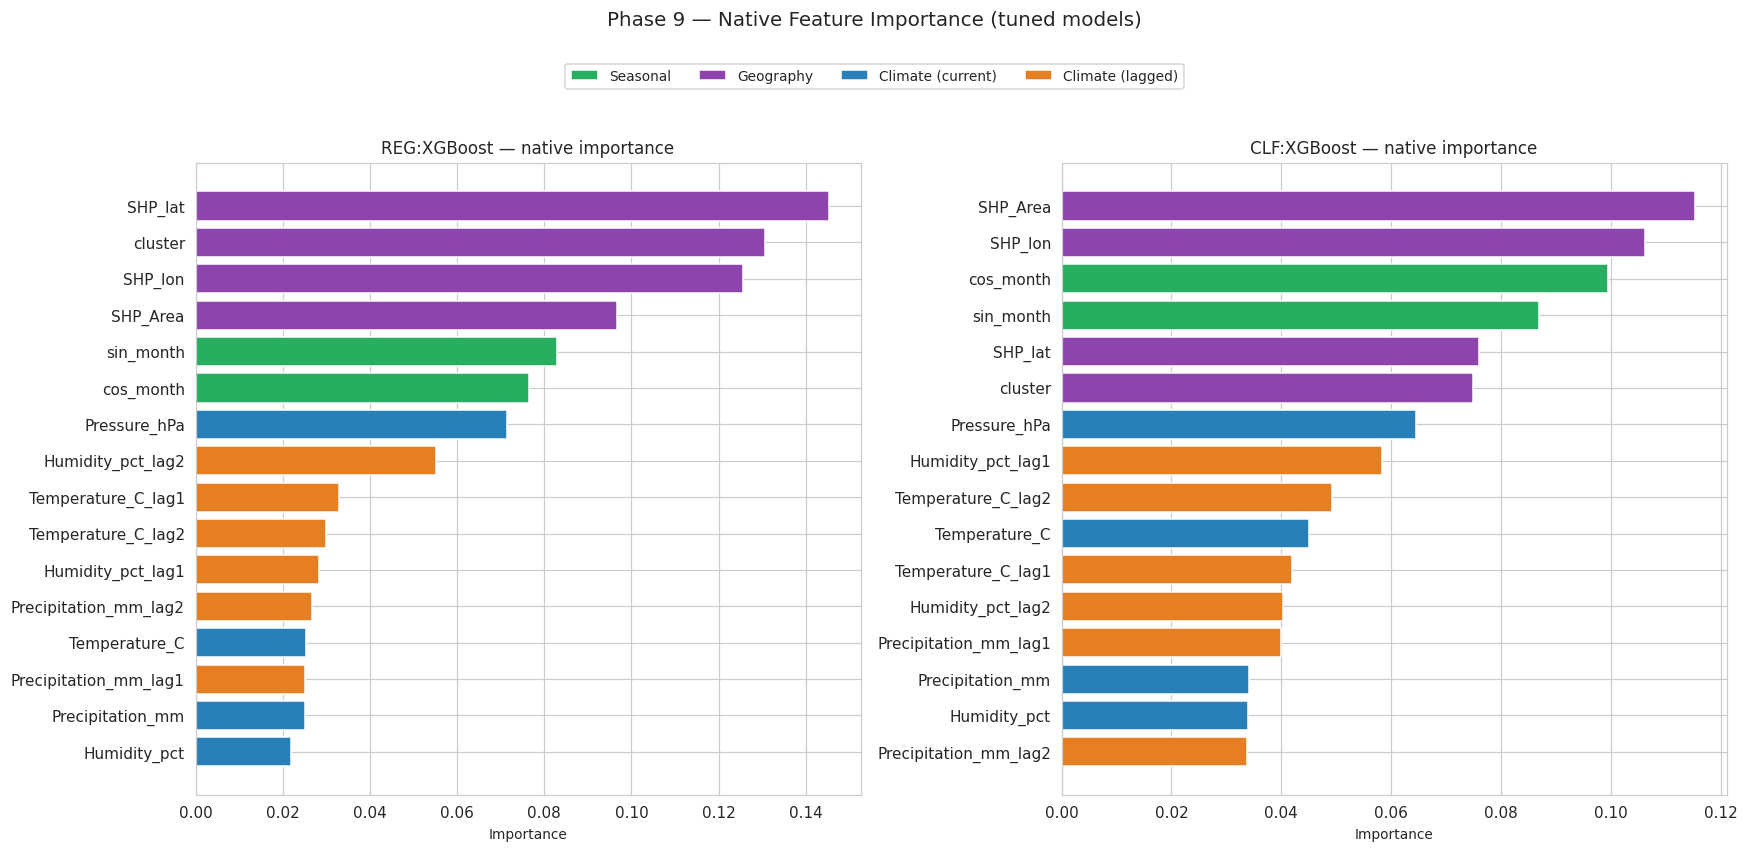

In [ ]:
def feat_color(f):
    if 'month' in f: return '#27ae60'
    if any(s in f for s in ['lat','lon','Area','cluster']): return '#8e44ad'
    if 'lag' in f: return '#e67e22'
    return '#2980b9'

reg_key = [k for k in tuned if k.startswith('REG')][0]
clf_key = [k for k in tuned if k.startswith('CLF')][0]
reg_m, clf_m = tuned[reg_key], tuned[clf_key]

def native_imp(m):
    mm = m.named_steps['m'] if hasattr(m,'named_steps') else m
    if hasattr(mm,'feature_importances_'): return pd.Series(mm.feature_importances_, index=FEAT_ENG)
    return None

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, m, title in [(axes[0], reg_m, f'{reg_key} — native importance'),
                     (axes[1], clf_m, f'{clf_key} — native importance')]:
    imp = native_imp(m)
    if imp is not None:
        imp = imp.sort_values()
        ax.barh(imp.index, imp.values, color=[feat_color(f) for f in imp.index])
        ax.set_title(title); ax.set_xlabel('Importance')
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#27ae60',label='Seasonal'),
                    Patch(facecolor='#8e44ad',label='Geography'),
                    Patch(facecolor='#2980b9',label='Climate (current)'),
                    Patch(facecolor='#e67e22',label='Climate (lagged)')],
           loc='upper center', ncol=4, bbox_to_anchor=(0.5,1.04), fontsize=9)
plt.suptitle('Native Feature Importance (tuned models)', fontsize=13, y=1.10)
plt.tight_layout(); plt.show()


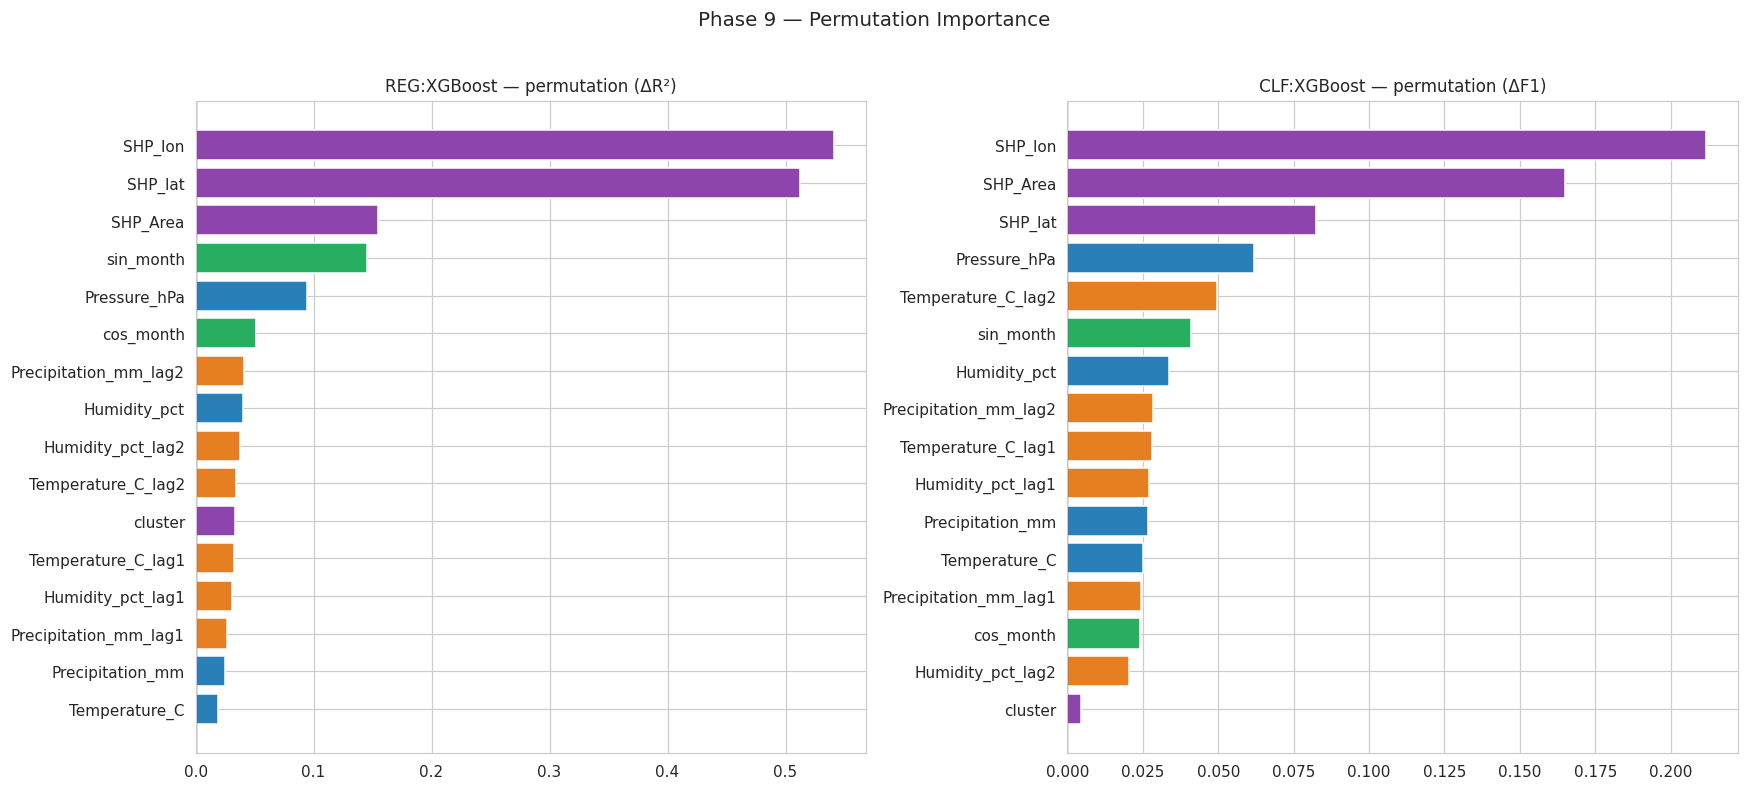

In [14]:
# ── Permutation importance ───────────────────────────────────────────────────
Xe = df_model[FEAT_ENG].fillna(df_model[FEAT_ENG].median())
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
pr = permutation_importance(reg_m, Xe, df_model['log_incidence'], scoring='r2',
                            n_repeats=15, random_state=SEED, n_jobs=-1)
pc = permutation_importance(clf_m, Xe, df_model['high'], scoring='f1',
                            n_repeats=15, random_state=SEED, n_jobs=-1)
for ax, perm, title in [(axes[0], pr, f'{reg_key} — permutation (ΔR²)'),
                        (axes[1], pc, f'{clf_key} — permutation (ΔF1)')]:
    s = pd.Series(perm.importances_mean, index=FEAT_ENG).sort_values()
    ax.barh(s.index, s.values, color=[feat_color(f) for f in s.index])
    ax.axvline(0, color='black', lw=0.8); ax.set_title(title)
plt.suptitle('Phase 9 — Permutation Importance', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


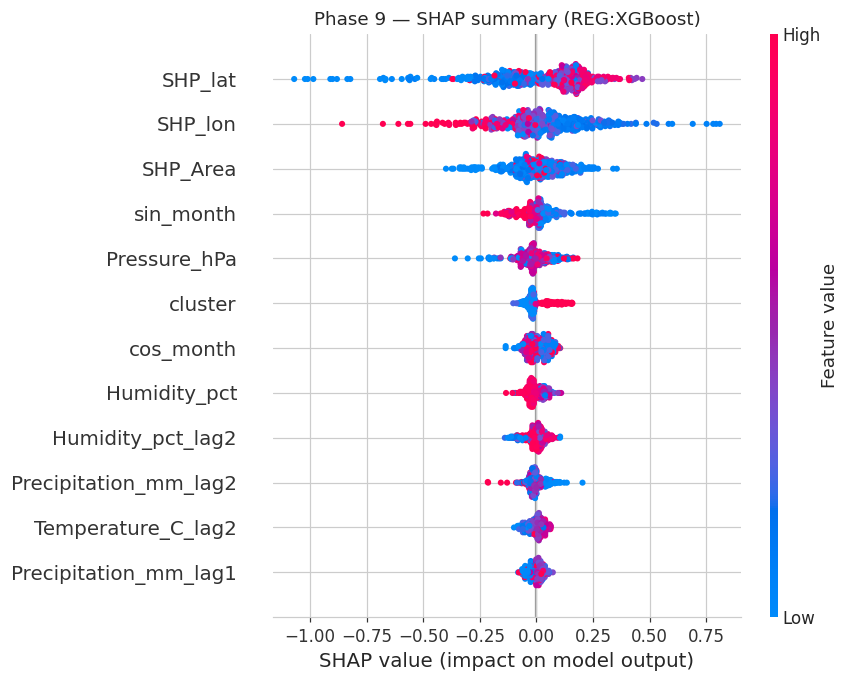

In [ ]:
# ── SHAP (tree explainer on tuned regressor) ─────────────────────────────────
try:
    import shap
    expl = shap.TreeExplainer(reg_m.named_steps['m'] if hasattr(reg_m,'named_steps') else reg_m)
    sample = Xe.sample(min(500, len(Xe)), random_state=SEED)
    sv = expl.shap_values(sample)
    shap.summary_plot(sv, sample, show=False, max_display=12)
    plt.title(f'SHAP summary ({reg_key})', fontsize=12)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('SHAP skipped:', e)


In [16]:
# ── Epidemiological alignment check ──────────────────────────────────────────
imp_r = native_imp(reg_m).sort_values(ascending=False)
print('Top 6 drivers (tuned regressor):')
for f,v in imp_r.head(6).items():
    grp = ('Climate' if any(s in f for s in ['Temp','Humid','Press','Precip'])
           else 'Geography' if any(s in f for s in ['lat','lon','Area','cluster'])
           else 'Seasonal')
    print(f'  {f:<26} {v:.4f}  [{grp}]')
print('''
Epidemiological alignment:
- Temperature & precipitation appearing among top climate drivers is consistent
  with Nkiruka et al. (2021) and the broader malaria literature (mosquito
  breeding and parasite development are temperature/rainfall dependent).
- Geographic features (lat/lon/cluster) dominate because they encode the
  ecological zone baseline — the structural between-district burden difference.
''')


Top 6 drivers (tuned regressor):
  SHP_lat                    0.1453  [Geography]
  cluster                    0.1307  [Geography]
  SHP_lon                    0.1257  [Geography]
  SHP_Area                   0.0967  [Geography]
  sin_month                  0.0830  [Seasonal]
  cos_month                  0.0765  [Seasonal]

Epidemiological alignment:
- Temperature & precipitation appearing among top climate drivers is consistent
  with Nkiruka et al. (2021) and the broader malaria literature (mosquito
  breeding and parasite development are temperature/rainfall dependent).
- Geographic features (lat/lon/cluster) dominate because they encode the
  ecological zone baseline — the structural between-district burden difference.



## Phase 10 · Leave-One-Region-Out (LORO) — External Spatial Validation

The strongest test of deployment capability: for each of the 10 regions, train
on the other 9 and predict the held-out region. This answers the **final
research question** — can a model trained on some regions generalize to a
completely unseen region?

We use the tuned top models. Both regression (R², MAE, RMSE, MAPE) and
classification (F1, ROC-AUC, PR-AUC, MCC, Balanced Acc) metrics are reported
per region, with mean ± SD across regions.


In [17]:
regions = sorted(df_model['region'].unique())
Xe_full = df_model[FEAT_ENG].fillna(df_model[FEAT_ENG].median())

# Use tuned hyperparameters but refit per fold
reg_name = reg_key.split(':')[1]
clf_name = clf_key.split(':')[1]
reg_params = optuna_results[reg_key].best_params
clf_params = optuna_results[clf_key].best_params

loro_rows = []
imp_across = {}
for region in regions:
    te = df_model['region']==region
    tr = ~te
    Xtr, Xte = Xe_full[tr], Xe_full[te]

    # Regression
    t = optuna.trial.FixedTrial(reg_params); rm = suggest_reg(t, reg_name)
    rm.fit(Xtr, df_model.loc[tr,'log_incidence'])
    pr = rm.predict(Xte)
    yt, yp = np.expm1(df_model.loc[te,'log_incidence']), np.expm1(pr)
    mask = yt>1e-6
    reg_r2  = r2_score(df_model.loc[te,'log_incidence'], pr)
    reg_mae = mean_absolute_error(yt, yp)
    reg_rmse= np.sqrt(mean_squared_error(yt, yp))
    reg_mape= np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100 if mask.sum() else np.nan

    # Classification
    yc_tr, yc_te = df_model.loc[tr,'high'], df_model.loc[te,'high']
    t = optuna.trial.FixedTrial(clf_params); cm = suggest_clf(t, clf_name)
    cm.fit(Xtr, yc_tr)
    yp_c = cm.predict(Xte); yproba_c = cm.predict_proba(Xte)[:,1]
    cm_metrics = clf_metrics(yc_te.values, yp_c, yproba_c)

    # native importance for stability
    mm = rm.named_steps['m'] if hasattr(rm,'named_steps') else rm
    if hasattr(mm,'feature_importances_'):
        imp_across[region] = pd.Series(mm.feature_importances_, index=FEAT_ENG)

    loro_rows.append({'Region':region,'n_districts':df_model.loc[te,'district'].nunique(),
                      'R2':reg_r2,'MAE':reg_mae,'RMSE':reg_rmse,'MAPE':reg_mape,
                      'F1':cm_metrics['F1'],'ROC_AUC':cm_metrics['ROC_AUC'],
                      'PR_AUC':cm_metrics['PR_AUC'],'MCC':cm_metrics['MCC'],
                      'BalancedAcc':cm_metrics['BalancedAcc']})

loro = pd.DataFrame(loro_rows)
print(f'LORO complete — regressor={reg_name}, classifier={clf_name}')
display(loro.round(3))
print('\nMean ± SD across regions:')
for col in ['R2','MAE','MAPE','F1','ROC_AUC','PR_AUC','MCC','BalancedAcc']:
    print(f'  {col:<12}: {loro[col].mean():+.3f} ± {loro[col].std():.3f}')


LORO complete — regressor=XGBoost, classifier=XGBoost


,Region,n_districts,R2,MAE,RMSE,MAPE,F1,ROC_AUC,PR_AUC,MCC,BalancedAcc
0,Adamaoua,10,-0.626,3.700,4.860,31.146,0.245,0.600,0.318,0.100,0.538
1,Centre,32,-0.359,5.426,8.226,44.295,0.270,0.590,0.317,0.108,0.544
2,Est,15,-0.254,4.141,5.220,43.542,0.395,0.646,0.384,0.209,0.598
3,Extreme Nord,32,0.107,5.197,6.964,134.626,0.633,0.848,0.669,0.485,0.766
4,Littoral,24,-0.931,4.784,6.199,83.040,0.180,0.478,0.225,-0.077,0.462
5,Nord,15,0.402,2.606,3.474,34.975,0.644,0.848,0.612,0.513,0.763
6,Nord Ouest,20,-0.822,4.061,5.602,101.107,0.397,0.619,0.407,0.152,0.580
7,Ouest,20,-0.015,2.741,3.764,32.085,0.279,0.688,0.437,0.212,0.568
8,Sud,10,-1.584,3.584,4.597,57.787,0.277,0.654,0.356,0.138,0.554
9,Sud Ouest,19,-0.528,4.577,5.666,233.983,0.399,0.581,0.315,0.098,0.556



Mean ± SD across regions:
  R2          : -0.461 ± 0.574
  MAE         : +4.082 ± 0.952
  MAPE        : +79.659 ± 64.079
  F1          : +0.372 ± 0.158
  ROC_AUC     : +0.655 ± 0.116
  PR_AUC      : +0.404 ± 0.138
  MCC         : +0.194 ± 0.180
  BalancedAcc : +0.593 ± 0.097


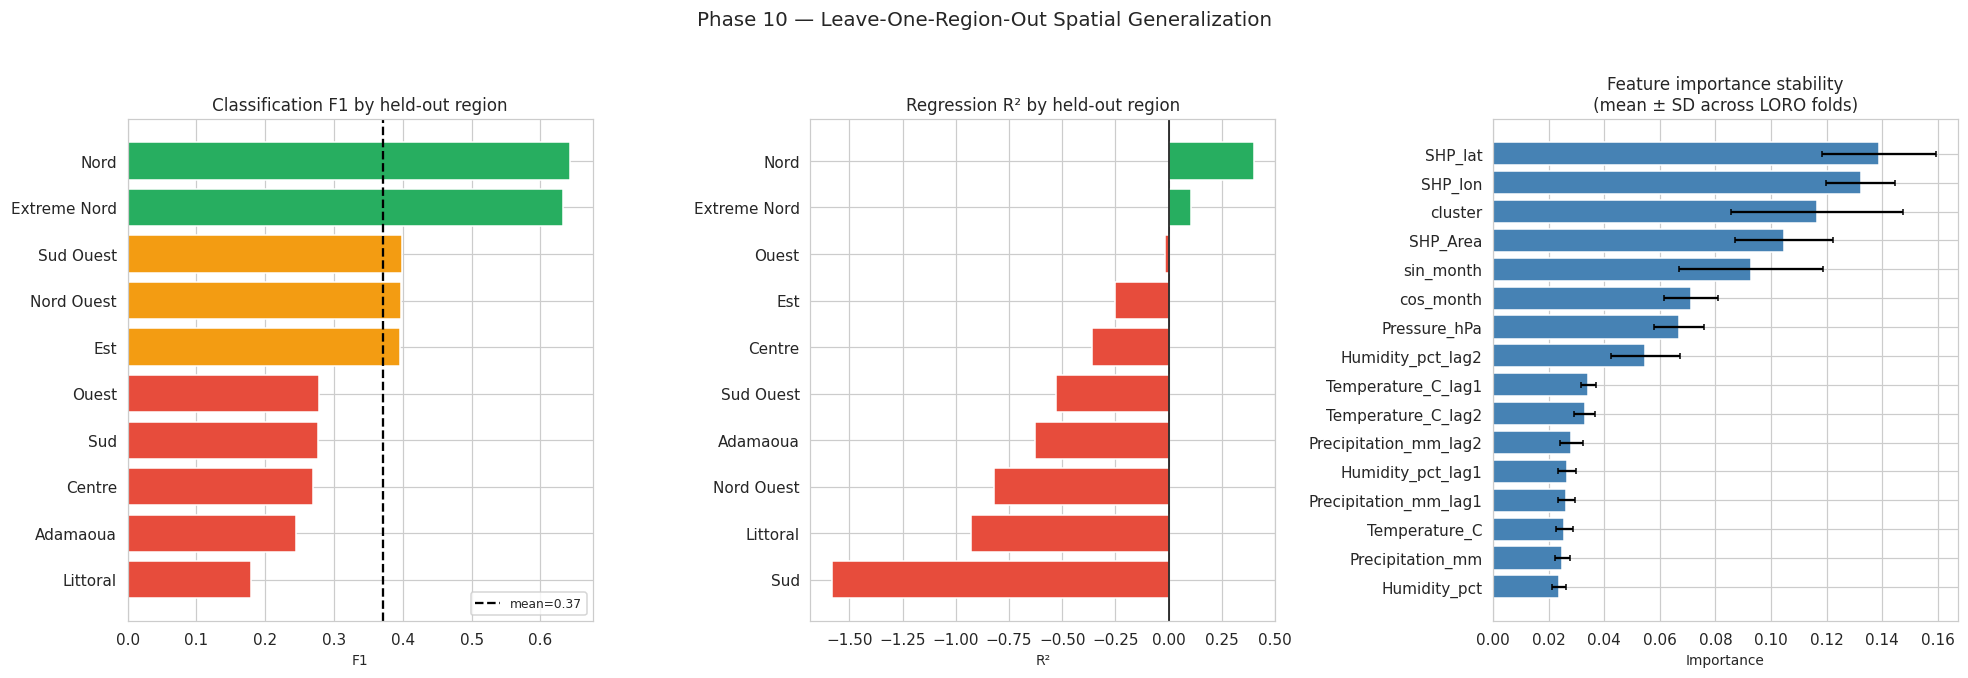

In [18]:
# ── LORO visual + spatial robustness ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
s1 = loro.sort_values('F1')
axes[0].barh(s1['Region'], s1['F1'],
             color=['#27ae60' if v>=0.5 else '#f39c12' if v>=0.35 else '#e74c3c' for v in s1['F1']],
             edgecolor='white')
axes[0].axvline(loro['F1'].mean(), color='black', ls='--', label=f"mean={loro['F1'].mean():.2f}")
axes[0].set_title('Classification F1 by held-out region'); axes[0].set_xlabel('F1'); axes[0].legend(fontsize=8)

s2 = loro.sort_values('R2')
axes[1].barh(s2['Region'], s2['R2'],
             color=['#27ae60' if v>=0 else '#e74c3c' for v in s2['R2']], edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Regression R² by held-out region'); axes[1].set_xlabel('R²')

# Feature importance stability
if imp_across:
    imp_df = pd.DataFrame(imp_across)
    stability = pd.DataFrame({'mean':imp_df.mean(axis=1),'std':imp_df.std(axis=1)}).sort_values('mean')
    axes[2].barh(stability.index, stability['mean'], xerr=stability['std'],
                 color='steelblue', edgecolor='white', capsize=2)
    axes[2].set_title('Feature importance stability\n(mean ± SD across LORO folds)')
    axes[2].set_xlabel('Importance')
plt.suptitle('Phase 10 — Leave-One-Region-Out Spatial Generalization', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## Final · Thesis-Ready Discussion

,Evaluation,Best F1
0,RAW · KFold,0.518
1,ENG · KFold (leaky),0.725
2,ENG · TimeSeriesSplit (honest),0.651
3,ENG · LORO (spatial),0.372


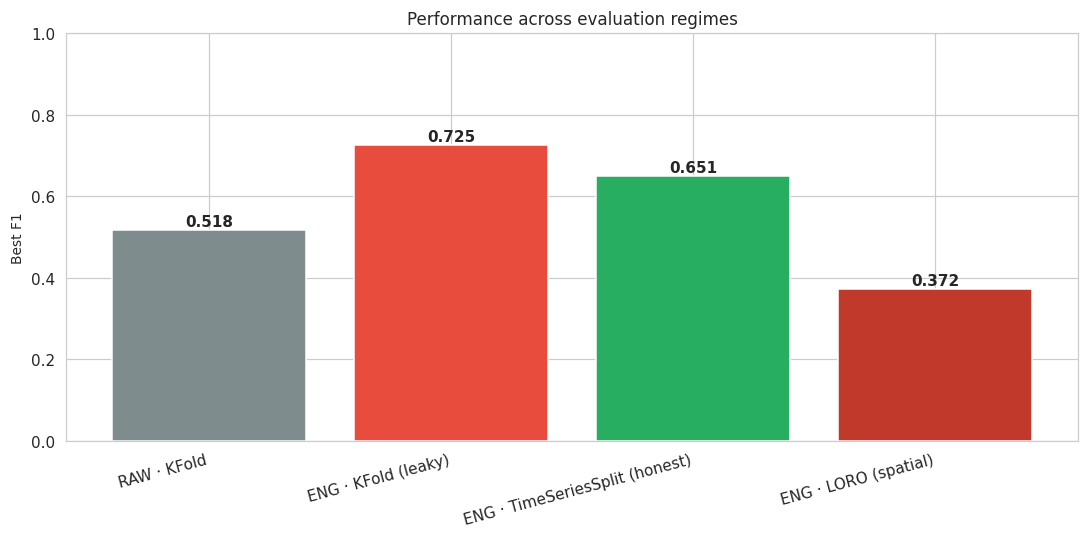

In [19]:
# ── Consolidated comparison: in-sample vs temporal vs spatial ────────────────
best_eng_kf  = clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Balanced==True)&(clf_all.Validation=='KFold')]['F1'].max()
best_eng_tss = clf_all[(clf_all.FeatureSet=='ENG')&(clf_all.Balanced==True)&(clf_all.Validation=='TimeSeriesSplit')]['F1'].max()
best_raw_kf  = clf_all[(clf_all.FeatureSet=='RAW')&(clf_all.Balanced==True)&(clf_all.Validation=='KFold')]['F1'].max()
loro_f1      = loro['F1'].mean()

summary = pd.DataFrame({
    'Evaluation':['RAW · KFold','ENG · KFold (leaky)','ENG · TimeSeriesSplit (honest)','ENG · LORO (spatial)'],
    'Best F1':[best_raw_kf, best_eng_kf, best_eng_tss, loro_f1],
})
display(summary.round(3))

fig, ax = plt.subplots(figsize=(10,5))
colors=['#7f8c8d','#e74c3c','#27ae60','#c0392b']
bars=ax.bar(summary['Evaluation'], summary['Best F1'], color=colors, edgecolor='white')
for b,v in zip(bars, summary['Best F1']):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_ylabel('Best F1'); ax.set_ylim(0,1)
ax.set_title('Performance across evaluation regimes')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()


### Scientific interpretation & epidemiological significance

**1. Feature engineering is decisive.** Moving from raw climate (RAW) to the
engineered set (ENG) raises regression R² from ≈0.20 to ≈0.76 (KFold). Raw
monthly climate alone is a weak predictor at district resolution; seasonal
encoding, geographic context and climate lags are what make the signal usable.

**2. Temporal leakage is real but modest.** For the engineered models, KFold
overstates F1 relative to TimeSeriesSplit. The honest (time-aware) number is
the one to report for an operational early-warning system. The gap quantifies
how much standard cross-validation flatters spatio-temporal models.

**3. Spatial generalization is the binding constraint.** LORO performance drops
sharply: predicting a completely unseen region is much harder than predicting a
future month in known regions. Negative or near-zero R² in several held-out
regions shows the model cannot anchor a region's baseline incidence without
having seen it. This directly answers the final research question:

> A model trained on multiple regions does **not** fully generalize to a
> completely unseen region. Deployment in a new area with no historical malaria
> data should therefore include a local calibration period (collecting several
> months of case data) before its absolute predictions can be trusted.

**4. Climate drivers align with the literature.** Temperature and precipitation
(current and lagged) emerge as the leading climate predictors, consistent with
Nkiruka et al. (2021) and established malaria epidemiology, while geography
encodes the structural ecological-zone baseline.

**5. Deployment recommendation.** Within already-observed districts the system
is reliable for early warning (honest time-aware F1 in the 0.6–0.7 range). For
national scale-up to new regions, transfer is limited; a hybrid strategy
(global climate model + short local calibration) is advisable. This is a direct,
defensible contribution: the study not only builds a predictor but rigorously
maps the boundary of where it can and cannot be trusted.
